In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

sys.path.insert(0, '/Users/dash/Documents/GitHub/bott')
from bott.io import load_tif

/opt/miniconda3/envs/BOttV03/bin/python
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)


In [2]:
#plt.close('all')
%matplotlib inline
#widget

In [3]:
import gpytorch

In [4]:
import torch, random, warnings
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.objective import GenericMCObjective
from botorch.models.gp_regression import SingleTaskGP
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.logei import (
    qLogExpectedImprovement,  # See https://arxiv.org/abs/2310.20708 for details.
)
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

# use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
torch.set_default_dtype(torch.float64)

In [5]:
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

In [6]:
def load(x):
    if isinstance(x, torch.Tensor):
        if len(x)==1: x=x[0].item()
    if isinstance(x, np.ndarray):
        if len(x)==1: x=x[0]
    roundedx = int( round(x / 5) * 5)
    try:
        print(f'For {x:.2f}, loaded {roundedx}')
        tag = f'../20250902-contour_tiles/imgs_noNorm_5A/th{roundedx}_tx0_ty0.tif'
        img = load_tif(tag) *1e5 #temporary scaling factor added on Nov 25
        #img = normalize(img)
    except:
        print('no such file: '+tag)
    return torch.Tensor(img)

In [7]:
# This is the correct value of the parameter
x_real = 350

# Get the PACBED at the thickness of x_real
y_raw = load(x_real) #[simulate(x_val) for x_val in x_obs]

# Upper and lower bounds for our search
lower = 100
upper = 495

For 350.00, loaded 350


In [ ]:
# scale_factor_for_plotting = 1#1e4

In [21]:
#get ground truth values from a preloaded images for plotting purpose

from PIL import Image
import torch
from bott.problem import OptimizationProblem
from bott.utils import normalize_arr
from bott.reduction import get_domain_tiles
from matplotlib.colors import TwoSlopeNorm
from bott.utils import safe_division
from botorch.sampling.normal import IIDNormalSampler, SobolQMCNormalSampler
from botorch.utils.sampling import draw_sobol_samples

params_abTEM = {  
    # Device configuration
    "device_abtem": 'mps',#"cpu",

    # Crystal structure input
    "path_crystal": "/Users/dash/Documents/Cornell/BOtt/20250500-exp_test/data/SrTiO3.cif",

    # Potential parameters
    "potential_extent_x": 62.6,  # Angstrom
    "potential_extent_y": 62.6,  # Angstrom
    "lateral_sampling": 0.2 * 2 / 3,  # Angstrom
    "vertical_sampling": 2,
    "potential_parametrization": "lobato",  # or "kirkland"
    "potential_projection": "finite",       # or "infinite"

    # Phonon parameters
    "random_seed": 42,
    "use_frozen_phonon": False,
    "num_phonon_configs": 5,
    "phonon_sigma": {
        'Sr': 0.088,
        'Ti': 0.0746,
        'O': 0.0963,
    },

    # Probe parameters
    "energy": 200e3,  # in eV
    "convergence_angle": 19.1,  # mrad
    "df": 0,
    "aberrations": {},

    "detector_angle": 31, #'cutoff', # mrad

    # Scan parameters
    "scan_step_size": 0.3,  # angstrom
    "return_pacbed": True,
}
sf_quad = 4303
sf_cent = 7440
temp = torch.Tensor([sf_cent, sf_quad, sf_quad, sf_quad, sf_quad])
sf_domain5seg = torch.sqrt(temp)

# OptimizationProblem would keep all the tensor on the specified device
problem = OptimizationProblem(ground_truth=torch.Tensor(y_raw),#torch.Tensor(expAdj), #
                              output_path='./output/', 
                              save_results=True, 
                              reduction_params={'reduction_type':'domain', 
                                                'reduction_kwargs':{'radius':0.31}},
                              loss_params={'loss_type':'SSE', 'dp_pow': 1}, 
                              norm_arr=False,
                              dim=3,#3, 
                              bounds=[(50,1000), (0, 10), (0,10)],
                              noise_std=0,
                              dtype=torch.float32, 
                              device='cpu',
                              params_abtem = params_abTEM,
                              scale_factor = sf_domain5seg,
                              ) # "cpu" or "cuda" for physics simulation

loss_func = problem.loss_func
reduction_true = problem.reduction_true.to(torch.float64) #patch term
measurement_true = problem.measurement_true.to(torch.float64) #ground_truth
sf_tile = problem.scaling_factor
#print(sf_tile) #wrong scaling factor here


thickness_range = np.arange(lower,upper,5) #19

arr_tiles= np.zeros((len(thickness_range),len(reduction_true)))
arr_patch_sse = np.zeros(len(thickness_range))
arr_pixel_sse = np.zeros_like(arr_patch_sse)
arr_multiplier = np.zeros_like(arr_patch_sse)

for ind_th, th in enumerate(thickness_range): #thickness #16
    ## load image to compare with ground truth
    #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
    temp_img = torch.Tensor(load(th)).to(torch.float64)
    
    # temp_pixel_loss = (temp_img-torch.Tensor(y_raw)).pow(2).sum(dim=(0,1)).numpy()
    # arr_patch_sse[ind_th] = temp_pixel_loss

    temp_pixel_loss = (temp_img-y_raw).pow(2).sum(dim=(0,1)).numpy()
    arr_pixel_sse[ind_th] = temp_pixel_loss

    temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
    arr_tiles[ind_th,:] = temp_patch.numpy()

    #20250902 edited here for correct scale factor
    temp_patch_loss = loss_func(y_simu=temp_patch *sf_tile, #0903: still need scale factor
                                y_true=reduction_true *sf_tile, 
                                reduce=False).numpy() #working correctly for SSE
    arr_patch_sse[ind_th] = temp_patch_loss

    temp_mult_factor = safe_division(temp_pixel_loss, temp_patch_loss,
                                    #threshold=1.5e-9,high_value = 200)
                                    threshold=1.5e-12,high_value = 500)
                                    #threshold=1.5e-12,high_value = 2000)
    
    print(f'pixel SSE: {temp_pixel_loss}, patch SSE: {temp_patch_loss}, multiplier: {temp_mult_factor}')
    arr_multiplier[ind_th] = temp_mult_factor

For 100.00, loaded 100
pixel SSE: 14890.696163293047, patch SSE: 918.0389633284829, multiplier: [[16.22011348]]
For 105.00, loaded 105
pixel SSE: 14126.083887356515, patch SSE: 1051.105311023274, multiplier: [[13.43926602]]
For 110.00, loaded 110
pixel SSE: 12840.440329405099, patch SSE: 1472.3608487073486, multiplier: [[8.72098735]]
For 115.00, loaded 115
pixel SSE: 12454.283360895082, patch SSE: 1662.7572089436806, multiplier: [[7.49013945]]
For 120.00, loaded 120
pixel SSE: 12245.75705696547, patch SSE: 1771.7051400421171, multiplier: [[6.91184824]]
For 125.00, loaded 125
pixel SSE: 12175.429967665608, patch SSE: 1776.9596304250758, multiplier: [[6.85183262]]
For 130.00, loaded 130
pixel SSE: 12232.916573976025, patch SSE: 1531.134814970359, multiplier: [[7.98944447]]
For 135.00, loaded 135
pixel SSE: 12263.12095569991, patch SSE: 1350.7121396280086, multiplier: [[9.07900403]]
For 140.00, loaded 140
pixel SSE: 12246.588035383356, patch SSE: 1178.6518734201538, multiplier: [[10.39033

/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_26565/2291374093.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  arr_multiplier[ind_th] = temp_mult_factor


In [38]:
thickness_range[50]

350

In [23]:
arr_patch_sse[0]

918.0399517507221

In [24]:
arr_pixel_sse[0]

14890.696163293047

In [25]:
arr_multiplier[0]

16.22009601531629

In [26]:
computeY( torch.Tensor(load(100)).to(torch.float32) )

For 100.00, loaded 100
patchTerm: tensor([812066.6684]), pixelTerm: tensor([14890.6962]), multiplier: tensor([0.0183])


tensor([[11.2449,  0.8039,  0.7696,  0.7696,  0.7347,  0.0183]])

In [27]:
patchesSSE(intoPatches( torch.Tensor(load(100)).to(torch.float32)) )

For 100.00, loaded 100


tensor([812066.6684])

In [9]:
arr_tiles

array([[11.24485302,  0.80394369,  0.76960331,  0.76960409,  0.73473704],
       [11.29787064,  0.77944154,  0.74219447,  0.74219495,  0.70520192],
       [11.39566803,  0.73114157,  0.69091642,  0.69091707,  0.65248412],
       [11.42831326,  0.71244645,  0.67236155,  0.67236197,  0.6346097 ],
       [11.44540882,  0.69958454,  0.66058594,  0.66058618,  0.62419939],
       [11.44663429,  0.69301987,  0.65575624,  0.65575653,  0.62108672],
       [11.41056728,  0.69600046,  0.66252863,  0.66252935,  0.6308195 ],
       [11.38150501,  0.70259839,  0.67037427,  0.67037451,  0.63925058],
       [11.35135365,  0.71026731,  0.67846107,  0.67846131,  0.6470722 ],
       [11.30332851,  0.72303057,  0.68927521,  0.68927562,  0.6549226 ],
       [11.28986168,  0.72631478,  0.69042957,  0.6904301 ,  0.65376186],
       [11.28399181,  0.7271415 ,  0.68871111,  0.68871152,  0.64956874],
       [11.28430462,  0.72575903,  0.6847136 ,  0.68471396,  0.64326906],
       [11.2936039 ,  0.71891481,  0.6

In [64]:
problem.reduction_func(y_raw)

tensor([10.9591,  0.6819,  0.6349,  0.6349,  0.5899])

In [63]:
y_patC

tensor([10.9591,  0.6819,  0.6349,  0.6349,  0.5899])

In [41]:
y_patC

tensor([0.8551, 0.0527, 0.0490, 0.0490, 0.0455])

In [67]:
patchesSSE(y_patC).shape

torch.Size([1])

In [50]:
computeY(y_raw)

patchTerm: tensor([0.]), pixelTerm: tensor([0.]), multiplier: tensor([500.])


tensor([[ 10.9591,   0.6819,   0.6349,   0.6349,   0.5899, 500.0000]])

In [ ]:
computeObjectiveC( computeY(y_raw) )

patchTerm: tensor([0.]), pixelTerm: tensor([0.]), multiplier: tensor([500.])


tensor([[-0.]])

In [55]:
computeY( torch.Tensor(load(100)).to(torch.float32) )

For 100.00, loaded 100
patchTerm: tensor([918.0389]), pixelTerm: tensor([14890.6962]), multiplier: tensor([16.2201])


tensor([[11.2449,  0.8039,  0.7696,  0.7696,  0.7347, 16.2201]])

In [29]:
computeObjectiveC(computeY( y_raw ))

patchTerm: tensor([765487.0934]), pixelTerm: tensor([0.]), multiplier: tensor([0.])


tensor([[-0.]])

In [ ]:
y_patC

In [24]:
loss_func(y_simu=y_patC *sf_tile, #0903: still need scale factor
                            y_true=reduction_true *sf_tile, 
                            reduce=False).numpy()

array(4.00342824e-10)

In [39]:
ind=50
print(arr_patch_sse[ind],arr_pixel_sse[ind],arr_multiplier[ind])

0.0 0.0 500.0


In [40]:
reduction_true

tensor([10.9591,  0.6819,  0.6349,  0.6349,  0.5899], dtype=torch.float32)

In [25]:
y_patC.dtype

torch.float64

In [17]:
y_patC[0]

tensor(10.9591)

In [26]:
y_patC

tensor([10.9591,  0.6819,  0.6349,  0.6349,  0.5899])

In [59]:
computeObjectiveC(computeY( torch.Tensor(load(100)).to(torch.float32) ))

For 100.00, loaded 100
patchTerm: tensor([918.0389]), pixelTerm: tensor([14890.6962]), multiplier: tensor([16.2201])


tensor([[-14890.6962]])

In [23]:
# functions needed for plotting. Note the plotting_scale_factor of 1e4 applied here
# and some initializations for the values for the ground truth point.
#checked
def intoPatches(y_pred_raw):
    return problem.reduction_func(y_pred_raw)

y_patC = intoPatches(y_raw) # compute reference values for patches

#checked
def pixelSSE(y_pred_raw):
    err = y_pred_raw-y_raw # #one image y_obs: image I want to measure
    return np.power(err,2).sum(dim=(0,1)).unsqueeze(-1)

#checked
def patchesSSE(pat): #patches of y and RSS in 10 variables
    return loss_func(y_simu=pat *sf_tile, #0903: still need scale factor
                        y_true=y_patC *sf_tile, 
                        reduce=False).unsqueeze(-1) #(pat-y_patC).pow(2).sum().unsqueeze(-1)
    # return np.power(pat-y_patC,2).sum()

#checked; all tile terms including the erorr term. 
def computeY(y_pred_raw):
    pat = intoPatches(y_pred_raw)
    patchTerm = patchesSSE(pat)
    pixelTerm = pixelSSE(y_pred_raw)
    multiplier = torch.Tensor(safe_division(pixelTerm, patchTerm,
                                            threshold=1.5e-12,high_value = 500)).squeeze(0)
    print(f'patchTerm: {patchTerm}, pixelTerm: {pixelTerm}, multiplier: {multiplier}')
                                    # threshold=1.5e-9,high_value = 200)).squeeze(0)
    return torch.cat((pat,multiplier),dim=-1).unsqueeze(0) #y_pred

y_obsC = computeY(y_raw) # compute reference values

def computeObjectiveC(y_pred):
    return -((y_pred[...,:-1]*sf_tile-y_obsC[...,:-1]*sf_tile).pow(2).sum()*y_pred[...,-1]).unsqueeze(-1)

def add_dataC(new_x, x=None, y=None, obj=None):
    
    if x is None:
        x = torch.tensor([])
    if y is None:
        y = torch.tensor([])
    if obj is None:
        obj = torch.tensor([])
    new_y = computeY(load(new_x)) # y is a tensor
    new_obj = computeObjectiveC(new_y) # this is our objective

    # x and obj are both 2D tensors that are nx1
    # y is a 3D tensor that is nx20x20 -> 12
    x = torch.cat((x, new_x),dim=0)
    y = torch.cat((y, new_y),dim=0)
    obj = torch.cat((obj, torch.tensor(new_obj)),dim=0)
    return x.to(torch.double), y.to(torch.double), obj.to(torch.double)

def generate_initial_data(n_initial_points):    
    new_x = (
            draw_sobol_samples(
                bounds=torch.tensor([[lower], [upper]]).to(torch.double),
                n=n_initial_points,
                q=1,
            )
        )
    for i in range(n_initial_points):
        if i == 0:
            x,y,obj = add_dataC(new_x[i,...])
        else:
            x,y,obj = add_dataC(new_x[i,...],x,y,obj)
    return x,y,obj

patchTerm: tensor([0.]), pixelTerm: tensor([0.]), multiplier: tensor([500.])


In [13]:
from botorch.models.transforms import Standardize
from botorch.models.transforms.input import Normalize

In [ ]:
# plot_name = [f'Patch {i} Model' for i in range(1,6)] + ['Multiplier'] + ['Objective'] + ['EI']

In [27]:
x_domain = torch.arange(lower, upper, 2.5).unsqueeze(-1).to(torch.double) #[79,1]
def plot_model_EI_objonly(fig,axis,model,eval_x,eval_y,acqf,var_np, var_npEI):
    with gpytorch.settings.cholesky_jitter(1e-3):
        # ensure the grid contains the exact training xs
        X_plot = torch.unique(torch.sort(torch.cat([x_domain, eval_x])).values)

        #inner functions
        post_at_x_domain = model.posterior(X_plot.unsqueeze(-1))
        ## not being used?
        # mean_at_x_domain = post_at_x_domain.mean #[79,6]
        # std_at_x_domain = torch.sqrt(post_at_x_domain.variance) #[79,6]
        # lo_at_x_domain = mean_at_x_domain-1.96*std_at_x_domain
        # up_at_x_domain = mean_at_x_domain+1.96*std_at_x_domain

        #objective. outer function
        inner_sample = IIDNormalSampler(sample_shape=torch.Size([2048])) #define based sample
        samples = inner_sample(post_at_x_domain) # do the sample
        samples_obj = g(samples) #[2048, 79]
        samplesmean = samples_obj.mean(dim=0) #note: calc var and use standard deviation [79]
        samples_std = samples_obj.std(dim=0)
        samples_low = samplesmean - 1.96*samples_std # [N,1]
        samples_up = samplesmean + 1.96*samples_std
        
        axis[0].plot(x,g(eval_y).squeeze(0).detach().numpy(),
                    marker='*', linestyle='none', markersize=10, color='black')
        axis[0].plot(X_plot,samplesmean.detach().numpy(),
                    color='red',linewidth=2,label='Prediction')
        axis[0].fill_between(X_plot,samples_low.squeeze().detach().numpy(),
                            samples_up.squeeze().detach().numpy(),
                            alpha=0.2,color='red',label='Uncertainty')
        axis[0].plot(thickness_range,-arr_pixel_sse,'k:')

        #print(f'y axis limits: {axis[0].get_ylim()}')
        #axis[0].legend()

        acqf_val = acqf(x_domain.unsqueeze(-1))
        #axis[1].set_title(plot_name[count_idx])
        axis[1].plot(x_domain,acqf_val.detach().numpy(),color='green',label='EI')
        axis[1].plot(var_np.detach().numpy(),var_npEI.detach().numpy(),
                    marker='*',linestyle='none', markersize=10, color='yellow',label='Candidate')
        #axis[1].legend()
        #plt.suptitle(f"Iteration {iter_no}", fontsize=14, y=0.91)  # Reduce `y` to bring closer
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust subplot grid to fit universal title
        #plt.show()

In [66]:
X_plot = torch.unique(torch.sort(torch.cat([x_domain, x])).values)

#inner functions
post_at_x_domain = model.posterior(X_plot.unsqueeze(-1))
## not being used?
mean_at_x_domain = post_at_x_domain.mean #[79,6]
std_at_x_domain = torch.sqrt(post_at_x_domain.variance) #[79,6]
lo_at_x_domain = mean_at_x_domain-1.96*std_at_x_domain
up_at_x_domain = mean_at_x_domain+1.96*std_at_x_domain

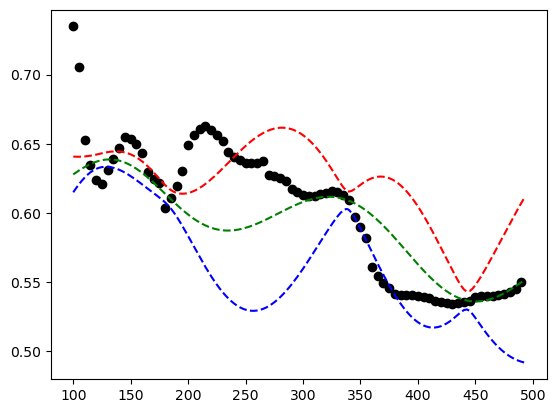

In [78]:
ind =4#5
plt.figure()
#plt.plot(thickness_range, arr_multiplier,'ko')
plt.plot(thickness_range, arr_tiles[:,ind],'ko')
plt.plot(X_plot,mean_at_x_domain[:,ind].detach().numpy(),'g--')
plt.plot(X_plot,lo_at_x_domain[:,ind].detach().numpy(),'b--')
plt.plot(X_plot,up_at_x_domain[:,ind].detach().numpy(),'r--')

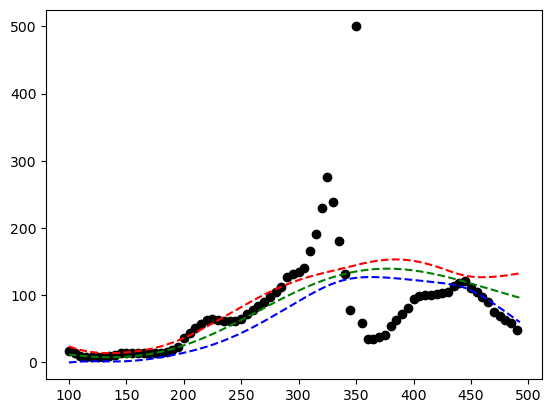

In [79]:
ind =5
plt.figure()
plt.plot(thickness_range, arr_multiplier,'ko')
plt.plot(X_plot,mean_at_x_domain[:,ind].detach().numpy(),'g--')
plt.plot(X_plot,lo_at_x_domain[:,ind].detach().numpy(),'b--')
plt.plot(X_plot,up_at_x_domain[:,ind].detach().numpy(),'r--')

objective is too small. what is going on?

For 289.71, loaded 290
patchTerm: tensor([38.1210]), pixelTerm: tensor([4805.4020]), multiplier: tensor([126.0567])
For 393.34, loaded 395
patchTerm: tensor([43.5397]), pixelTerm: tensor([3503.6240]), multiplier: tensor([80.4697])
Best value (thickness,obj) found: 393.33778804168105 , tensor([-3503.6240])
Best value found: -3503.6240253155393
iteration #0. best_obj: -3503.6240253155393


/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_26565/4021724272.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obj = torch.cat((obj, torch.tensor(new_obj)),dim=0)


new_point_EI val: 6.1848
Iteration 1, measuring at x=377.8779776121153
For 377.88, loaded 380
patchTerm: tensor([43.1303]), pixelTerm: tensor([2310.6829]), multiplier: tensor([53.5745])
Best value (thickness,obj) found at 2: 377.8779776121153 , -2310.682948340748
iteration #1. best_obj: -2310.682948340748
new_point_EI val: 6.6164
Iteration 2, measuring at x=333.96831962470065
For 333.97, loaded 335
patchTerm: tensor([4.9860]), pixelTerm: tensor([899.4748]), multiplier: tensor([180.3997])
Best value (thickness,obj) found at 3: 333.96831962470065 , -899.474837132657
iteration #2. best_obj: -899.474837132657
new_point_EI val: 6.3994
Iteration 3, measuring at x=343.29075073005754
For 343.29, loaded 345
patchTerm: tensor([0.7835]), pixelTerm: tensor([60.5343]), multiplier: tensor([77.2594])
Best value (thickness,obj) found at 4: 343.29075073005754 , -60.5342667622869
iteration #3. best_obj: -60.5342667622869
new_point_EI val: 3.7666
Iteration 4, measuring at x=346.59815196927735
For 346.60,

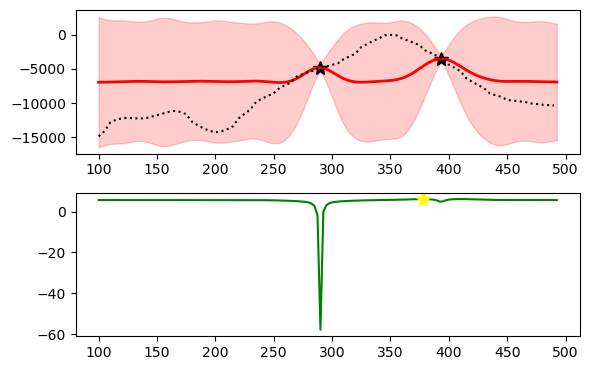

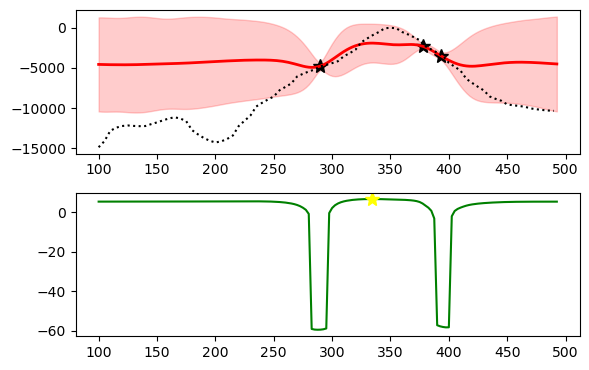

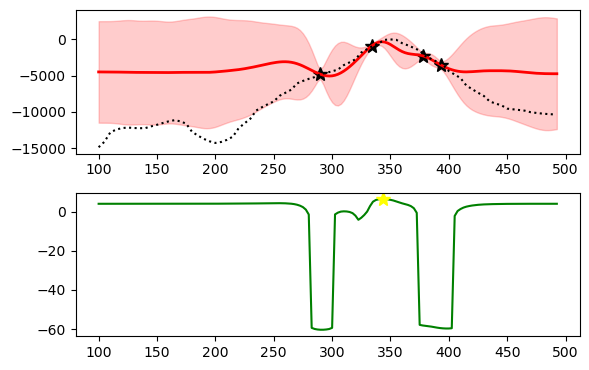

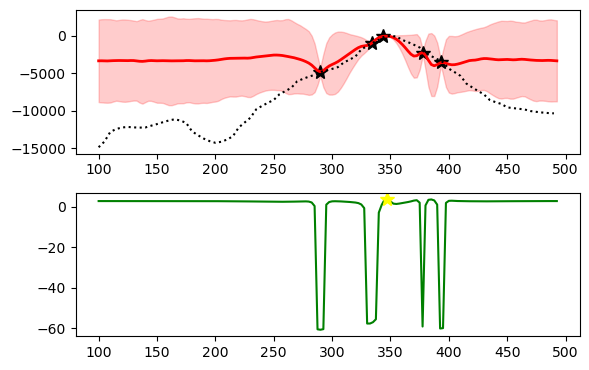

In [29]:
start = datetime.now()
seed = 5
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
n_initial_points = 2
n_BO_points = 4

# Generate initial data: several datapoints at random
# Each one of them will be uniform between 0 and 3
x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
g = GenericMCObjective(objective=lambda _y,X=None: - (torch.sum( (_y[...,:-1]*sf_tile-torch.tensor(y_obsC[...,:-1]).unsqueeze(0)*sf_tile).pow(2) , dim=-1)*_y[...,-1]) )
best = [obj.max().detach().item()] # This will store the best value
best_x_idx = obj.argmax()
print('Best value (thickness,obj) found: {} , {}'.format(x[best_x_idx].item(),obj[best_x_idx]))
print('Best value found: {}'.format(best[-1]))


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
#     with gpytorch.settings.cholesky_jitter(1e-3):
        #warnings.filterwarnings('ignore',category=InputDataWarning)
    for i in range(n_BO_points):

        # Fit the model
        #noise = torch.ones_like(y) * 0.0001
        model = SingleTaskGP(x, y, outcome_transform=Standardize(m=6),input_transform=Normalize(d=1)) # GP is on y, not the objective
        # model = SingleTaskGP(x, y) # GP is on y, not the objective
        fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
        ###question
        #g = GenericMCObjective(objective=lambda _y: -(_y[:,:9]-torch.tensor(y_obsC[:9])).pow(2).mean(dim=-1) +_y[:,9] )
        #... for the batch. Whatever dimension in front then the dimension that i specify.
        #From 100 initial points, chooses 50 initial best points for the gradient descent
        best_obj = g(y).max() # same as -obj.min()
        print("iteration #{}. best_obj: {}".format(i,best_obj))
        sampler = SobolQMCNormalSampler(torch.Size([1024])).to(dtype=dtype)
        EICF = qLogExpectedImprovement(model=model, best_f=best_obj, objective=g,sampler=sampler).to(dtype=dtype)
        new_point, new_point_EI = optimize_acqf(
            acq_function=EICF,
            bounds=torch.tensor([[lower], [upper]]).to(dtype=dtype),
            q=1,
            num_restarts=50,
            raw_samples=100,
        )
        print(f"new_point_EI val: {new_point_EI:.5}")
        fig,axis = plt.subplots(2, 1, figsize=(6,4))    
        # Plot the posterior and the EI
        plot_model_EI_objonly(fig=fig,axis=axis,model=model,eval_x = x, eval_y=y,acqf=EICF,
                            var_np=new_point,var_npEI = new_point_EI)#,iter_no=i+1)
        #axis[0].set_ylim(-0.0157, 0.0026)
        #axis[0].set_ylim(-15700, 3348)
        print('Iteration {}, measuring at x={}'.format(i+1,new_point.item()) )
        
        x,y,obj = add_dataC(new_point,x,y,obj)
        best.append(obj.max().item())
        best_x_idx = obj.argmax()
        print('Best value (thickness,obj) found at {}: {} , {}'.format(best_x_idx,
                                                                    x[best_x_idx].item(),
                                                                    obj.max()))
# torch.cuda.synchronize()
end = datetime.now()
print('Time elapsed (hh:mm:ss.ms):  {} '.format(end-start))

### seed 5

For 289.71, loaded 290
For 393.34, loaded 395
Best value (thickness,obj) found: 393.33778804168105 , tensor([-3503.6238], dtype=torch.float64)
Best value found: -3503.623779296875
iteration #0. best_obj: -3503.624042022823


/var/folders/6g/x0m1vg9s7dzb28pr980bgk_w0000gn/T/ipykernel_2962/401145724.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obj = torch.cat((obj, torch.tensor(new_obj)),dim=0)


new_point_EI val: 645.92
Iteration 1, measuring at x=375.0893859863281
For 375.09, loaded 375
Best value (thickness,obj) found at 2: 375.0893859863281 , -1541.6412353515625
iteration #1. best_obj: -1541.6411706628278
new_point_EI val: 641.7
Iteration 2, measuring at x=345.6178894042969
For 345.62, loaded 345
Best value (thickness,obj) found at 3: 345.6178894042969 , -60.534263610839844
iteration #2. best_obj: -60.53426657819303
new_point_EI val: 35.631
Iteration 3, measuring at x=348.68798828125
For 348.69, loaded 350
Best value (thickness,obj) found at 4: 348.68798828125 , -0.0
iteration #3. best_obj: -0.0
new_point_EI val: 26.545
Iteration 4, measuring at x=475.70416259765625
For 475.70, loaded 475
Best value (thickness,obj) found at 4: 348.68798828125 , -0.0
iteration #4. best_obj: -0.0
new_point_EI val: 33.612
Iteration 5, measuring at x=100.0
For 100.00, loaded 100
Best value (thickness,obj) found at 4: 348.68798828125 , -0.0
iteration #5. best_obj: -0.0
new_point_EI val: 2342.7
I

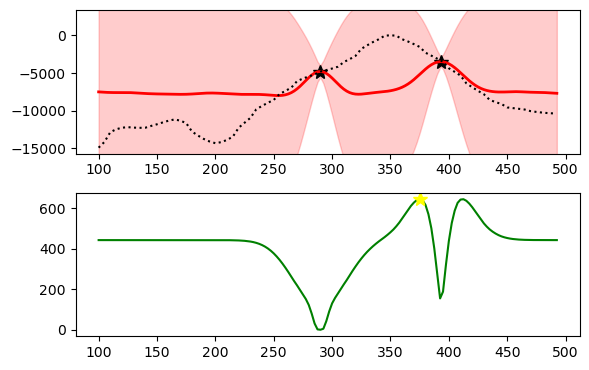

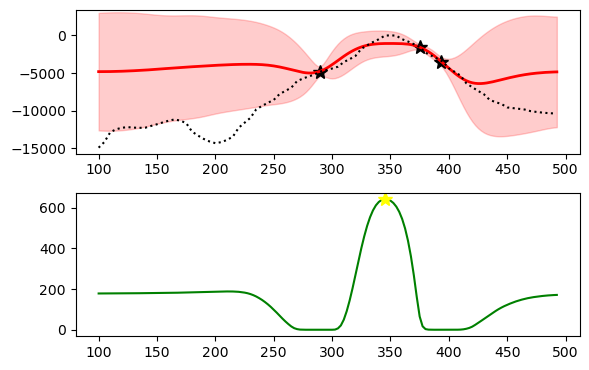

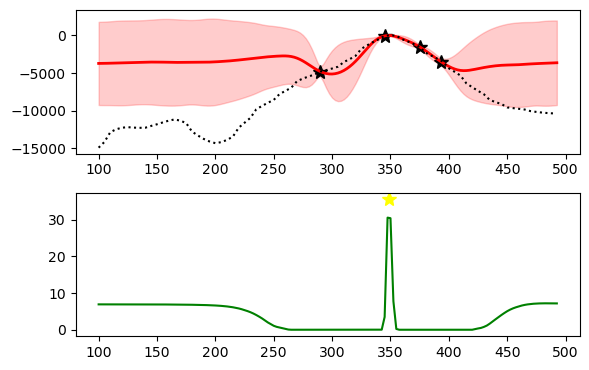

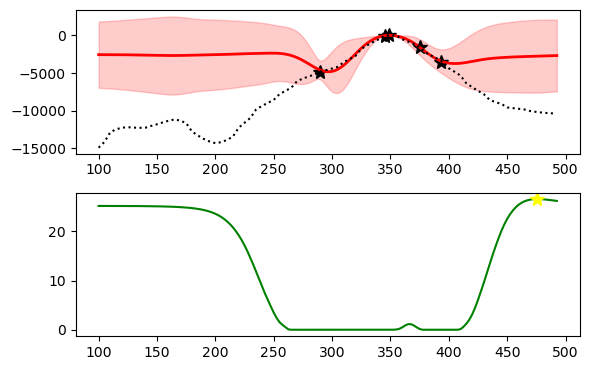

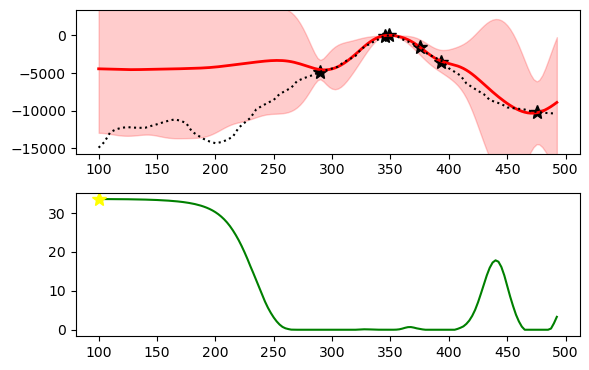

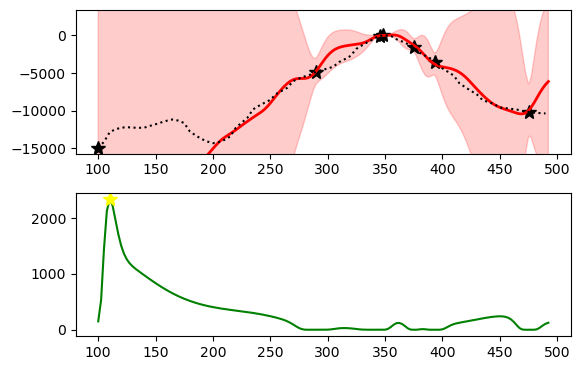

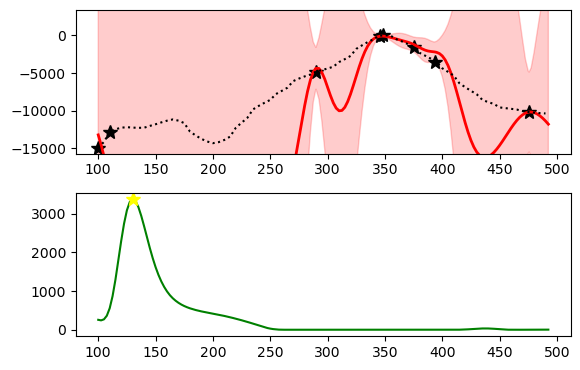

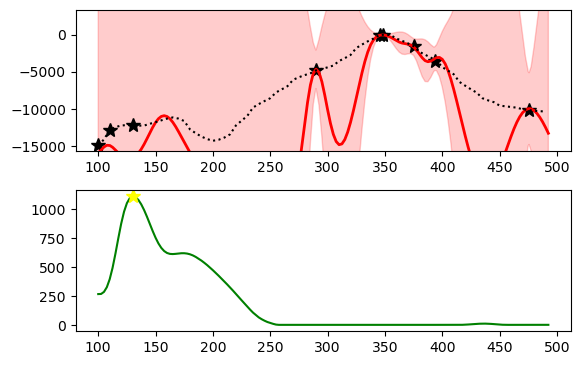

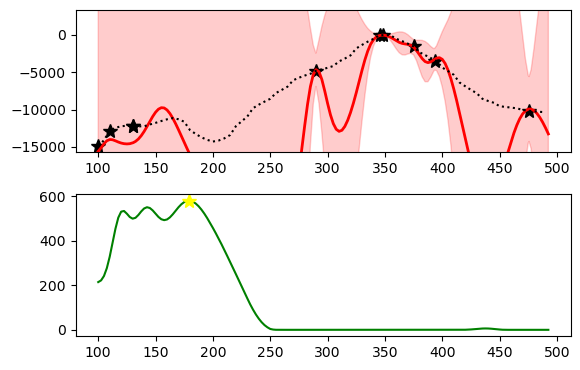

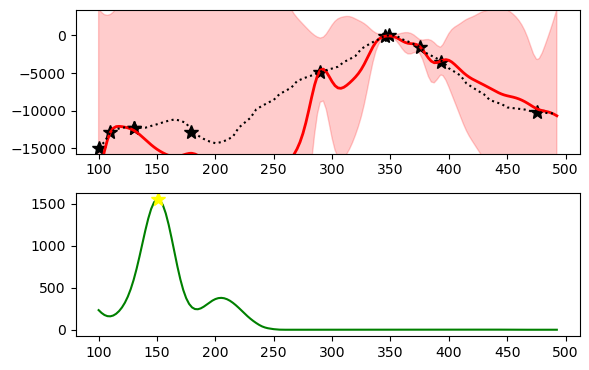

In [37]:
#just the final objective and EI for now
start = datetime.now()
seed = 5
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
n_initial_points = 2
n_BO_points = 10

# Generate initial data: several datapoints at random
# Each one of them will be uniform between 0 and 3
x,y,obj = generate_initial_data(n_initial_points=n_initial_points)
g = GenericMCObjective(objective=lambda _y,X=None: - scale_factor_for_plotting*(torch.sum( (_y[...,:-1]-torch.tensor(y_obsC[...,:-1]).unsqueeze(0)).pow(2) , dim=-1)*_y[...,-1]) )
best = [obj.max().detach().item()] # This will store the best value
best_x_idx = obj.argmax()
print('Best value (thickness,obj) found: {} , {}'.format(x[best_x_idx].item(),obj[best_x_idx]))
print('Best value found: {}'.format(best[-1]))


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    #warnings.filterwarnings('ignore',category=InputDataWarning)
    for i in range(n_BO_points):
    
        # Fit the model
        #noise = torch.ones_like(y) * 0.0001
        model = SingleTaskGP(x, y, outcome_transform=Standardize(m=6),input_transform=Normalize(d=1)) # GP is on y, not the objective
        # model = SingleTaskGP(x, y) # GP is on y, not the objective
        fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
        ###question
        #g = GenericMCObjective(objective=lambda _y: -(_y[:,:9]-torch.tensor(y_obsC[:9])).pow(2).mean(dim=-1) +_y[:,9] )
        #... for the batch. Whatever dimension in front then the dimension that i specify.
        #From 100 initial points, chooses 50 initial best points for the gradient descent
        best_obj = g(y).max() # same as -obj.min()
        print("iteration #{}. best_obj: {}".format(i,best_obj))
        sampler = SobolQMCNormalSampler(torch.Size([1024]))
        EI = qExpectedImprovement(model=model, best_f=best_obj, objective=g,sampler=sampler)
        new_point, new_point_EI = optimize_acqf(
            acq_function=EI,
            bounds=torch.tensor([[lower], [upper]]).float(),
            q=1,
            num_restarts=50,
            raw_samples=100,
        )
        print(f"new_point_EI val: {new_point_EI:.5}")
        fig,axis = plt.subplots(2, 1, figsize=(6,4))    
        # Plot the posterior and the EI
        plot_model_EI_objonly(fig=fig,axis=axis,model=model,eval_x = x, acqf=EI,iter_no=i+1)
        #axis[0].set_ylim(-0.0157, 0.0026)
        axis[0].set_ylim(-15700, 3348)
        print('Iteration {}, measuring at x={}'.format(i+1,new_point.item()) )
        
        x,y,obj = add_dataC(new_point,x,y,obj)
        best.append(obj.max().item())
        best_x_idx = obj.argmax()
        print('Best value (thickness,obj) found at {}: {} , {}'.format(best_x_idx,
                                                                       x[best_x_idx].item(),
                                                                       obj.max()))
# torch.cuda.synchronize()
end = datetime.now()
print('Time elapsed (hh:mm:ss.ms):  {} '.format(end-start))